In [5]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

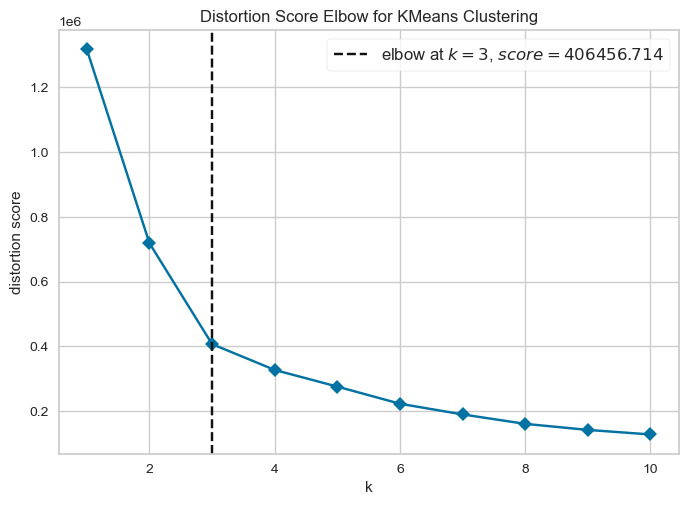

In [6]:
data_path = '../../../../data/processed_data/main_datasets/data_with_generated_features.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(X_pca)
visualizer.show();

Как мы видим, точка в которой происходит значительное снижение скорости уменьшения inertia находится при количестве кластеров равном 3

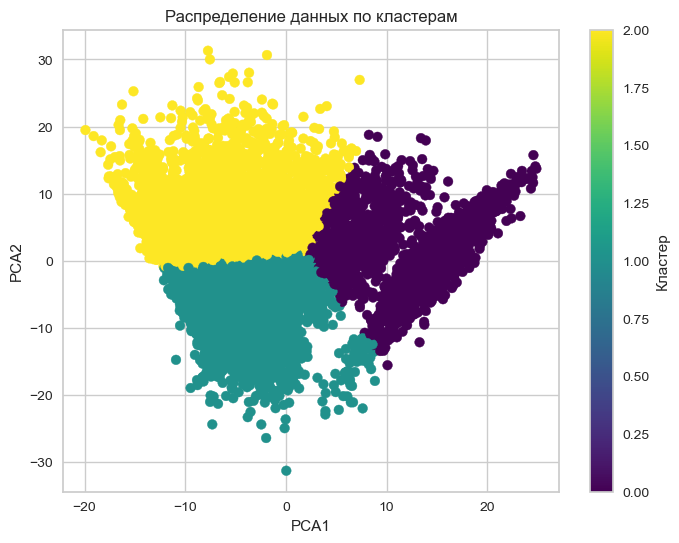

In [7]:
n_clusters = visualizer.elbow_value_

kmeans = KMeans(n_clusters=3, random_state=42) 
kmeans.fit(X_pca)

data['Cluster'] = kmeans.labels_

data['PCA1'] = X_pca[:, 0]
data['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(data['PCA1'], data['PCA2'], c=data['Cluster'], cmap='viridis')
plt.title('Распределение данных по кластерам')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Кластер')
plt.show()

In [8]:
output_path = '../../../../data/processed_data/train_models_data/data_with_PCA/data_with_generated_features/KMeans_generated_features_PCA.csv'
data.to_csv(output_path, index=False)